## Housing Price Prediction using Machine Learning

In this machine learning and data analysis, the Ames Housing Price dataset was used, containing data for residential homes in Ames, Iowa from 2006 to 2010. The original data set was compiled by Dean De Cock (Truman State University) and contains 2930 observations with 79 features. The target variable we will be exploring is "SalePrice", the sale price of homes in Ames. 

## Machine Learning techniques

For price prediction we will use decision tree learning, a supervised learning approach. Using a regression decision tree, we will extract predictions for housing prices.

Decision tree learning is a strong first choice for this problem because it can capture nonlinear relationships and feature interactions that are common in housing data. Decision trees work well with both numerical and categorical variables with minimal preprocessing. 

In [1]:
import pandas as pd

# ORIGINAL DATASET:

ames = pd.read_csv("AmesHousing.csv")

# VIEW ORIGINAL DATASET
ames

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


We will select some key features to use for our machine learning model: 

I started with a subset of highly interpretable features to help build intuition and create this first baseline ML model for the Ames housing dataset. 

In [2]:
selected_features = [
    "Overall Qual",  # Overall material and finish quality
    "Gr Liv Area",    # Above grade living area (finished living space above ground) in square feet
    "Garage Cars",   # Size of garage in car capacity
    "1st Flr SF",     # First floor square footage
    "Year Built",    # Year the house was built
    "Kitchen Qual",  # Kitchen quality
    "Lot Area",      # Lot size in square feet
    "Neighborhood",  # Neighborhood location within Ames
    "SalePrice", # Sale price of the house
]

In [3]:
ames_data = ames[selected_features]
ames_data

,Overall Qual,Gr Liv Area,Garage Cars,1st Flr SF,Year Built,Kitchen Qual,Lot Area,Neighborhood,SalePrice
0,6,1656,2.0,1656,1960,TA,31770,NAmes,215000
1,5,896,1.0,896,1961,TA,11622,NAmes,105000
2,6,1329,1.0,1329,1958,Gd,14267,NAmes,172000
3,7,2110,2.0,2110,1968,Ex,11160,NAmes,244000
4,5,1629,2.0,928,1997,TA,13830,Gilbert,189900
...,...,...,...,...,...,...,...,...,...
2925,6,1003,2.0,1003,1984,TA,7937,Mitchel,142500
2926,5,902,2.0,902,1983,TA,8885,Mitchel,131000
2927,5,970,0.0,970,1992,TA,10441,Mitchel,132000
2928,5,1389,2.0,1389,1974,TA,10010,Mitchel,170000


Check for NA values and look at unique values:

In [4]:
for column in ames_data.columns:
    print(f"Column: {column}")
    print("Missing values:", ames_data[column].isna().sum())
    print("Unique values:", ames_data[column].unique())
    print("-" * 40)


Column: Overall Qual
Missing values: 0
Unique values: [ 6  5  7  8  9  4  3  2 10  1]
----------------------------------------
Column: Gr Liv Area
Missing values: 0
Unique values: [1656  896 1329 ... 2028 2521 1003]
----------------------------------------
Column: Garage Cars
Missing values: 1
Unique values: [ 2.  1.  3.  0.  4.  5. nan]
----------------------------------------
Column: 1st Flr SF
Missing values: 0
Unique values: [1656  896 1329 ... 2028 1003 1389]
----------------------------------------
Column: Year Built
Missing values: 0
Unique values: [1960 1961 1958 1968 1997 1998 2001 1992 1995 1999 1993 1990 1985 2003
 1988 2010 1951 1978 1977 1974 2000 1970 1971 1975 2009 2007 2005 2004
 2002 2006 1996 1994 2008 1980 1979 1984 1920 1965 1967 1963 1962 1976
 1972 1966 1959 1964 1950 1952 1949 1940 1954 1955 1957 1956 1953 1948
 1900 1910 1927 1915 1945 1929 1938 1923 1928 1890 1885 1922 1925 1939
 1942 1936 1930 1921 1912 1917 1907 1875 1969 1947 1946 1987 1941 1924
 1914 1931 1

In [5]:
# map kitchen qualities to easy to discern names

quality_mapping = {
    "TA": 2, # Typical/Average
    "Gd": 3, # Good
    "Ex": 4, # Excellent
    "Fa": 1, # Fair
    "Po": 0 # Poor
}

ames_data = ames_data.copy()

ames_data["Kitchen Qual"] = ames_data["Kitchen Qual"].replace(quality_mapping)

ames_data

,Overall Qual,Gr Liv Area,Garage Cars,1st Flr SF,Year Built,Kitchen Qual,Lot Area,Neighborhood,SalePrice
0,6,1656,2.0,1656,1960,2,31770,NAmes,215000
1,5,896,1.0,896,1961,2,11622,NAmes,105000
2,6,1329,1.0,1329,1958,3,14267,NAmes,172000
3,7,2110,2.0,2110,1968,4,11160,NAmes,244000
4,5,1629,2.0,928,1997,2,13830,Gilbert,189900
...,...,...,...,...,...,...,...,...,...
2925,6,1003,2.0,1003,1984,2,7937,Mitchel,142500
2926,5,902,2.0,902,1983,2,8885,Mitchel,131000
2927,5,970,0.0,970,1992,2,10441,Mitchel,132000
2928,5,1389,2.0,1389,1974,2,10010,Mitchel,170000


In [6]:
ames_data = ames_data.copy()

ames_data.replace(["", " ", "NA", "null", "nan"], pd.NA, inplace=True)

ames_data = ames_data.copy()

# Drop the NAs
ames_data = ames_data.dropna()

In [7]:
for column in ames_data.columns:
    print(ames_data[column].isna().sum())
    print(ames_data[column].unique())

0
[ 6  5  7  8  9  4  3  2 10  1]
0
[1656  896 1329 ... 2028 2521 1003]
0
[2. 1. 3. 0. 4. 5.]
0
[1656  896 1329 ... 2028 1003 1389]
0
[1960 1961 1958 1968 1997 1998 2001 1992 1995 1999 1993 1990 1985 2003
 1988 2010 1951 1978 1977 1974 2000 1970 1971 1975 2009 2007 2005 2004
 2002 2006 1996 1994 2008 1980 1979 1984 1920 1965 1967 1963 1962 1976
 1972 1966 1959 1964 1950 1952 1949 1940 1954 1955 1957 1956 1953 1948
 1900 1910 1927 1915 1945 1929 1938 1923 1928 1890 1885 1922 1925 1939
 1942 1936 1930 1921 1912 1917 1907 1875 1969 1947 1946 1987 1941 1924
 1914 1931 1919 1989 1896 1973 1991 1981 1986 1916 1926 1935 1892 1898
 1880 1882 1937 1902 1934 1982 1983 1932 1918 1904 1905 1872 1893 1906
 1908 1911 1895 1879 1901 1913]
0
[2 3 4 1 0]
0
[31770 11622 14267 ...  7937  8885 10441]
0
['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 '

In [8]:
ames_data.dtypes

Overall Qual      int64
Gr Liv Area       int64
Garage Cars     float64
1st Flr SF        int64
Year Built        int64
Kitchen Qual      int64
Lot Area          int64
Neighborhood     object
SalePrice         int64
dtype: object

## EDA

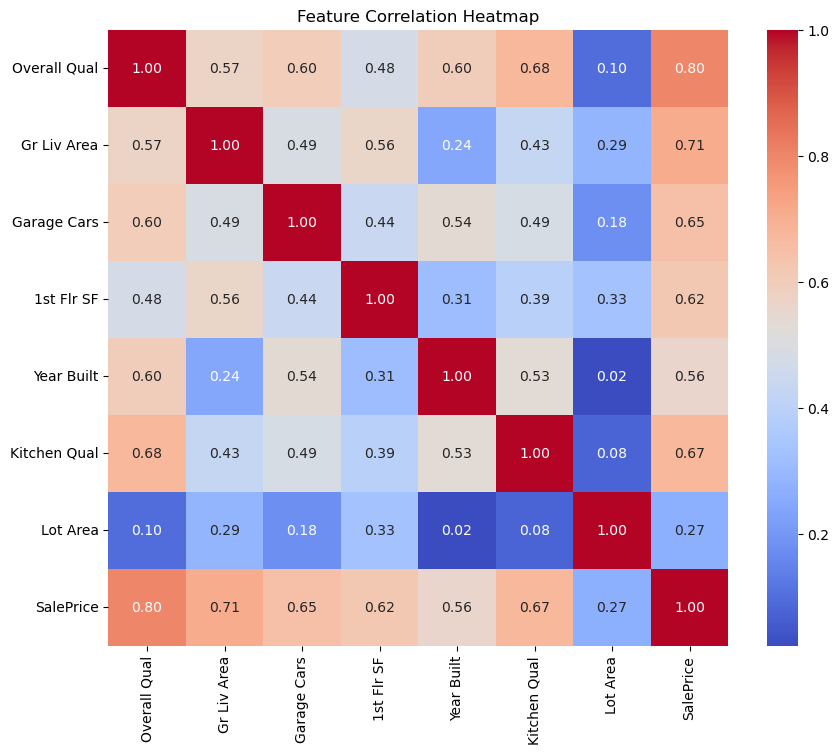

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix for numeric columns only
correlation_matrix = ames_data.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()


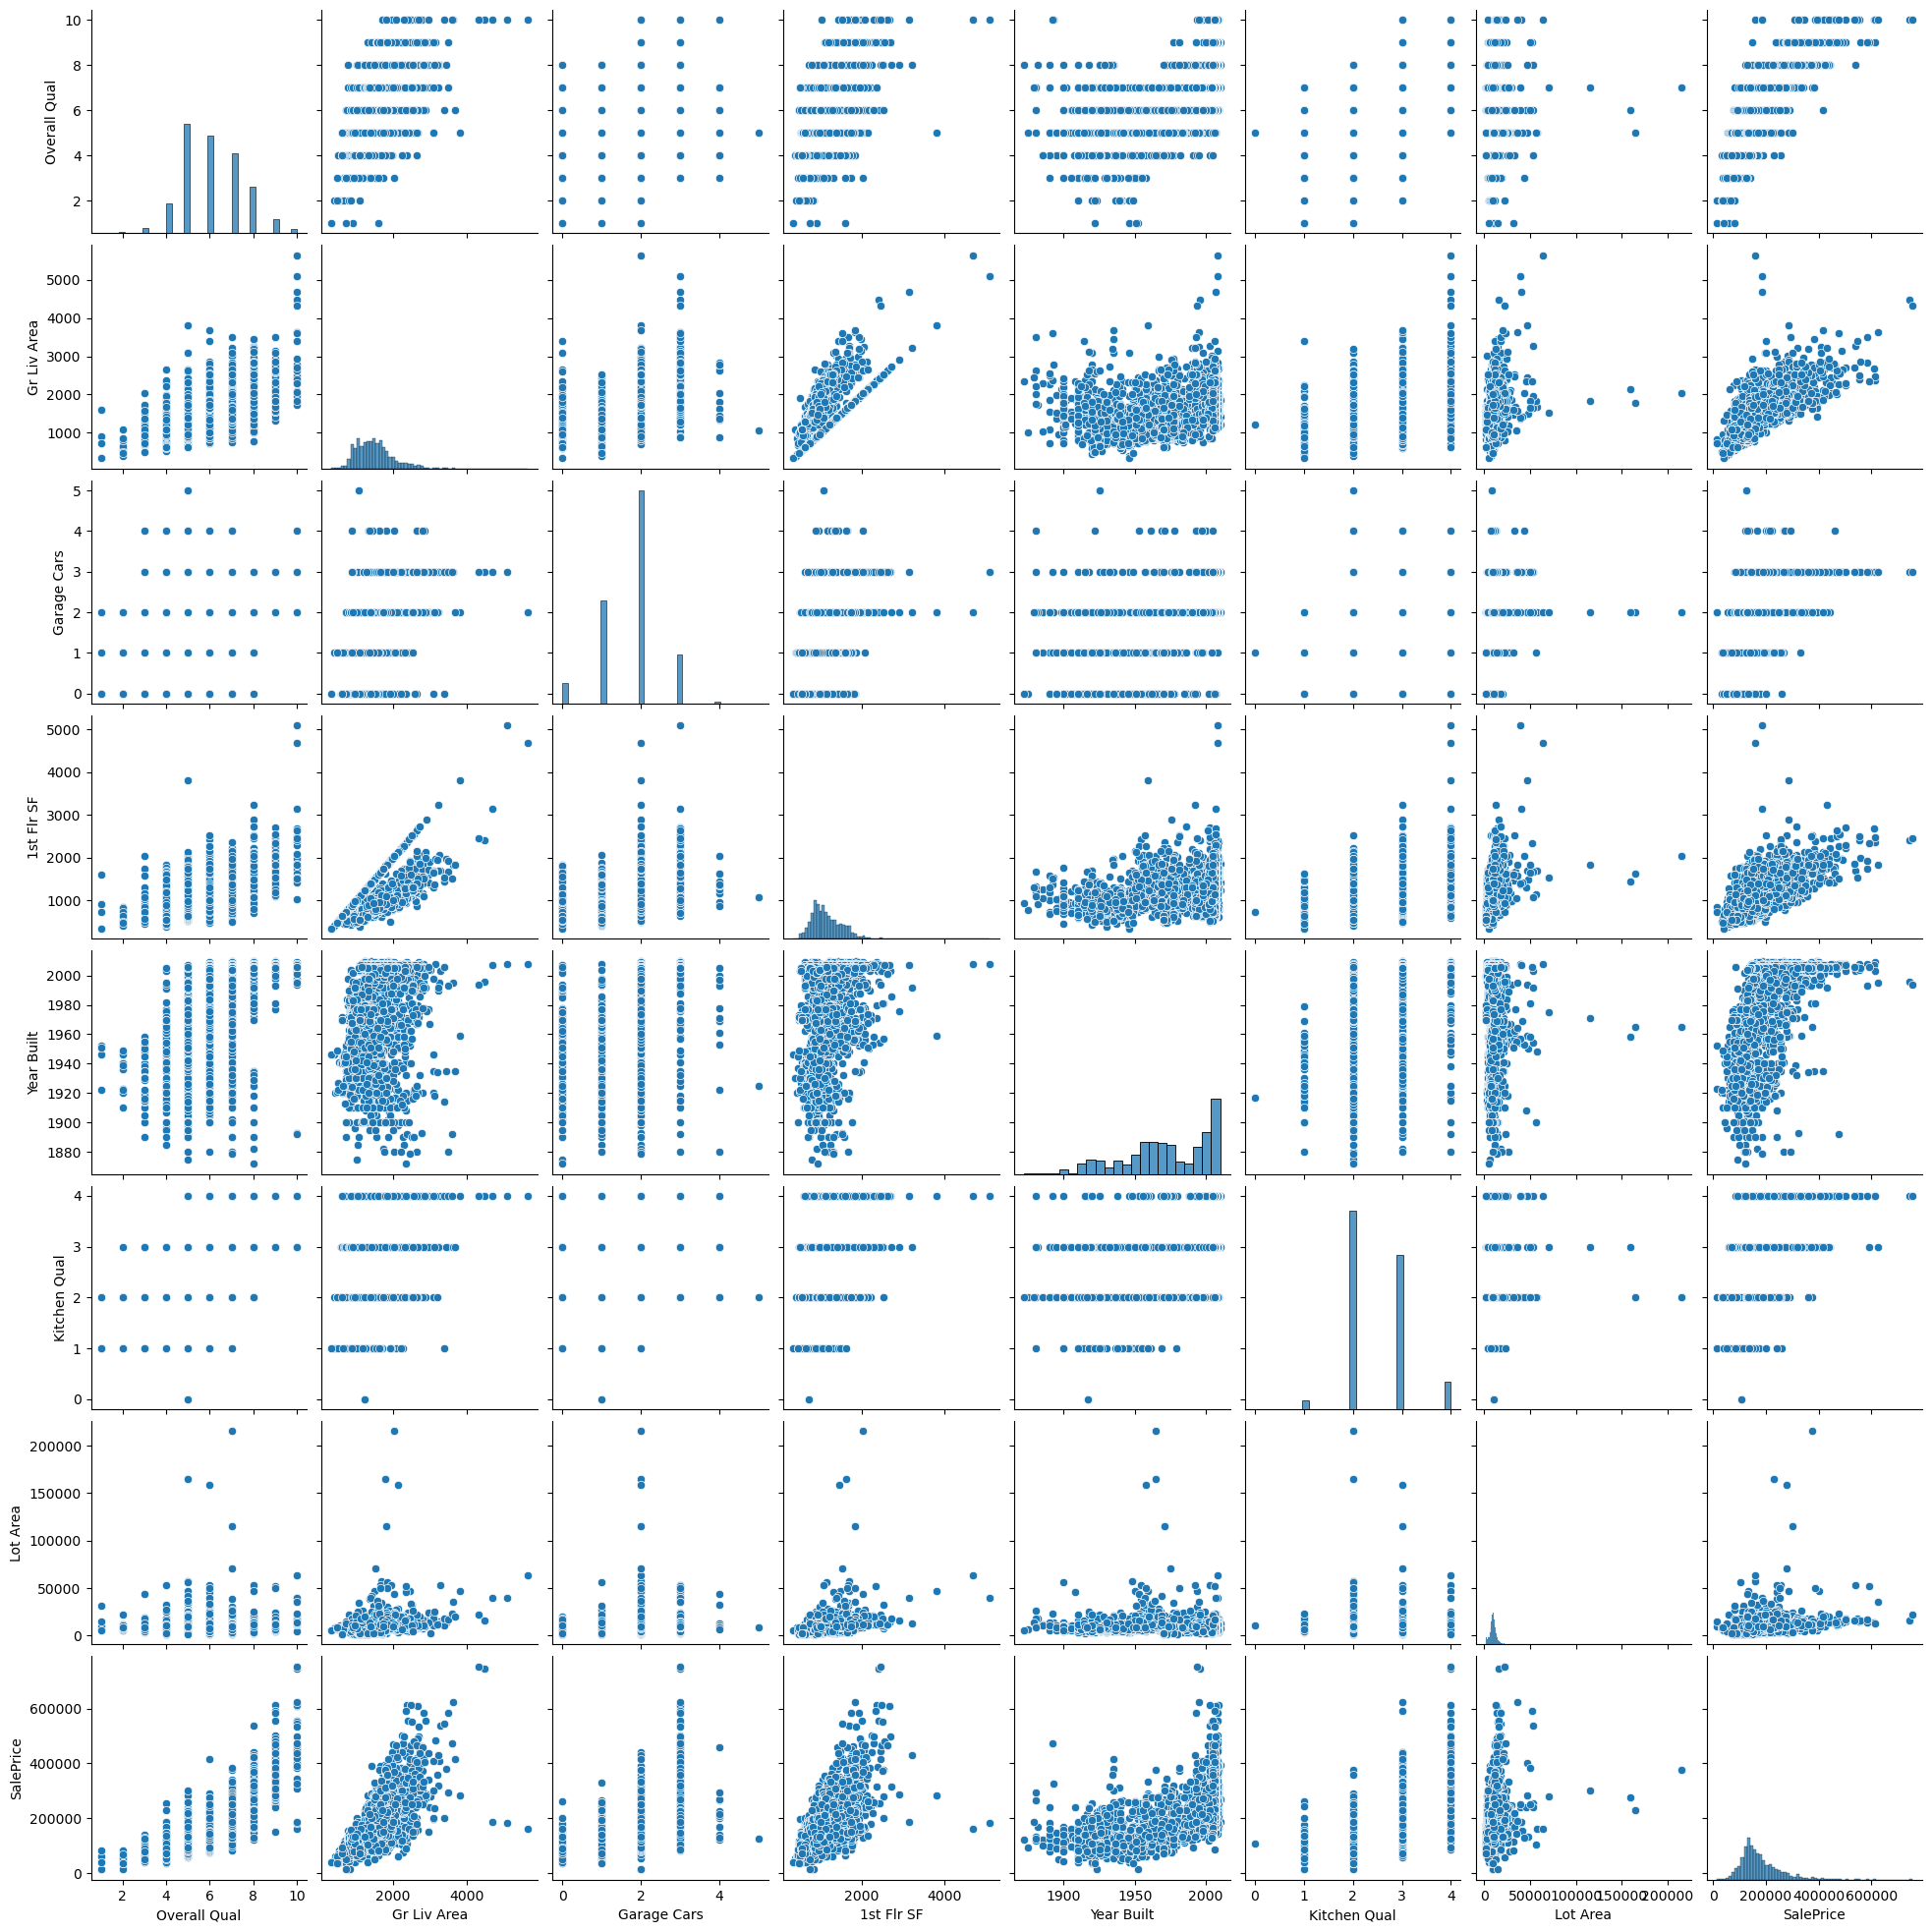

In [10]:
# Scatterplot matrix

# Select only numerical columns
numerical_columns = ames_data.select_dtypes(include=["number"]).columns

# Pairplot to show relationships between numerical columns
sns.pairplot(ames_data[numerical_columns])
plt.show()

The variables chosen don't have a ton of multicollinearity, the highest is KitchenQual and OverallQual at 0.68. Since I am using a decision tree model, I don't need to strictly enforce linear relationships or address multicollinearity. 

## Decision Trees (Regression task)

In [11]:
ames_data

,Overall Qual,Gr Liv Area,Garage Cars,1st Flr SF,Year Built,Kitchen Qual,Lot Area,Neighborhood,SalePrice
0,6,1656,2.0,1656,1960,2,31770,NAmes,215000
1,5,896,1.0,896,1961,2,11622,NAmes,105000
2,6,1329,1.0,1329,1958,3,14267,NAmes,172000
3,7,2110,2.0,2110,1968,4,11160,NAmes,244000
4,5,1629,2.0,928,1997,2,13830,Gilbert,189900
...,...,...,...,...,...,...,...,...,...
2925,6,1003,2.0,1003,1984,2,7937,Mitchel,142500
2926,5,902,2.0,902,1983,2,8885,Mitchel,131000
2927,5,970,0.0,970,1992,2,10441,Mitchel,132000
2928,5,1389,2.0,1389,1974,2,10010,Mitchel,170000


For Kitchen Qual we will use label encoding and for Neighborhood we will use one-hot encoding

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# One-Hot Encode Neighborhood
ames_data = pd.get_dummies(ames_data, columns=['Neighborhood'], drop_first=True)

X = ames_data.drop(columns=['SalePrice'])
y = ames_data['SalePrice']

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train on Decision Tree Regressor
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

# Predict on test set
y_pred = regressor.predict(X_test)

# Evaluate results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:")
print(mse)
print("R2:")
print(r2)

MSE:
1232321161.1552901
R2:
0.8364554302571416


The results of the Decision tree regression model results in a MSE of 1232321161.1552 and a $R^2$ of 0.8365. This indicates an average error of approximately 34,881.80 for each housing price. The $R^2$ indicates strong predictive value.

We can try to improve this by tuning hyperparameters such as max depth, minimum samples that must be present in an internal node for splitting, and minimum samples that must be present in a leaf.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    "max_depth": [3, 5, 10, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

tree = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(tree, param_grid, cv=5, scoring="r2")

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Best params:", grid_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
MSE: 880775216.1799179
R2: 0.883110013598017


## Visualizing Decision Tree

The decision tree for this housing price prediction is too large to fully visualize but printing the first 4 branches of the tree gives a good idea of how the decision tree works.

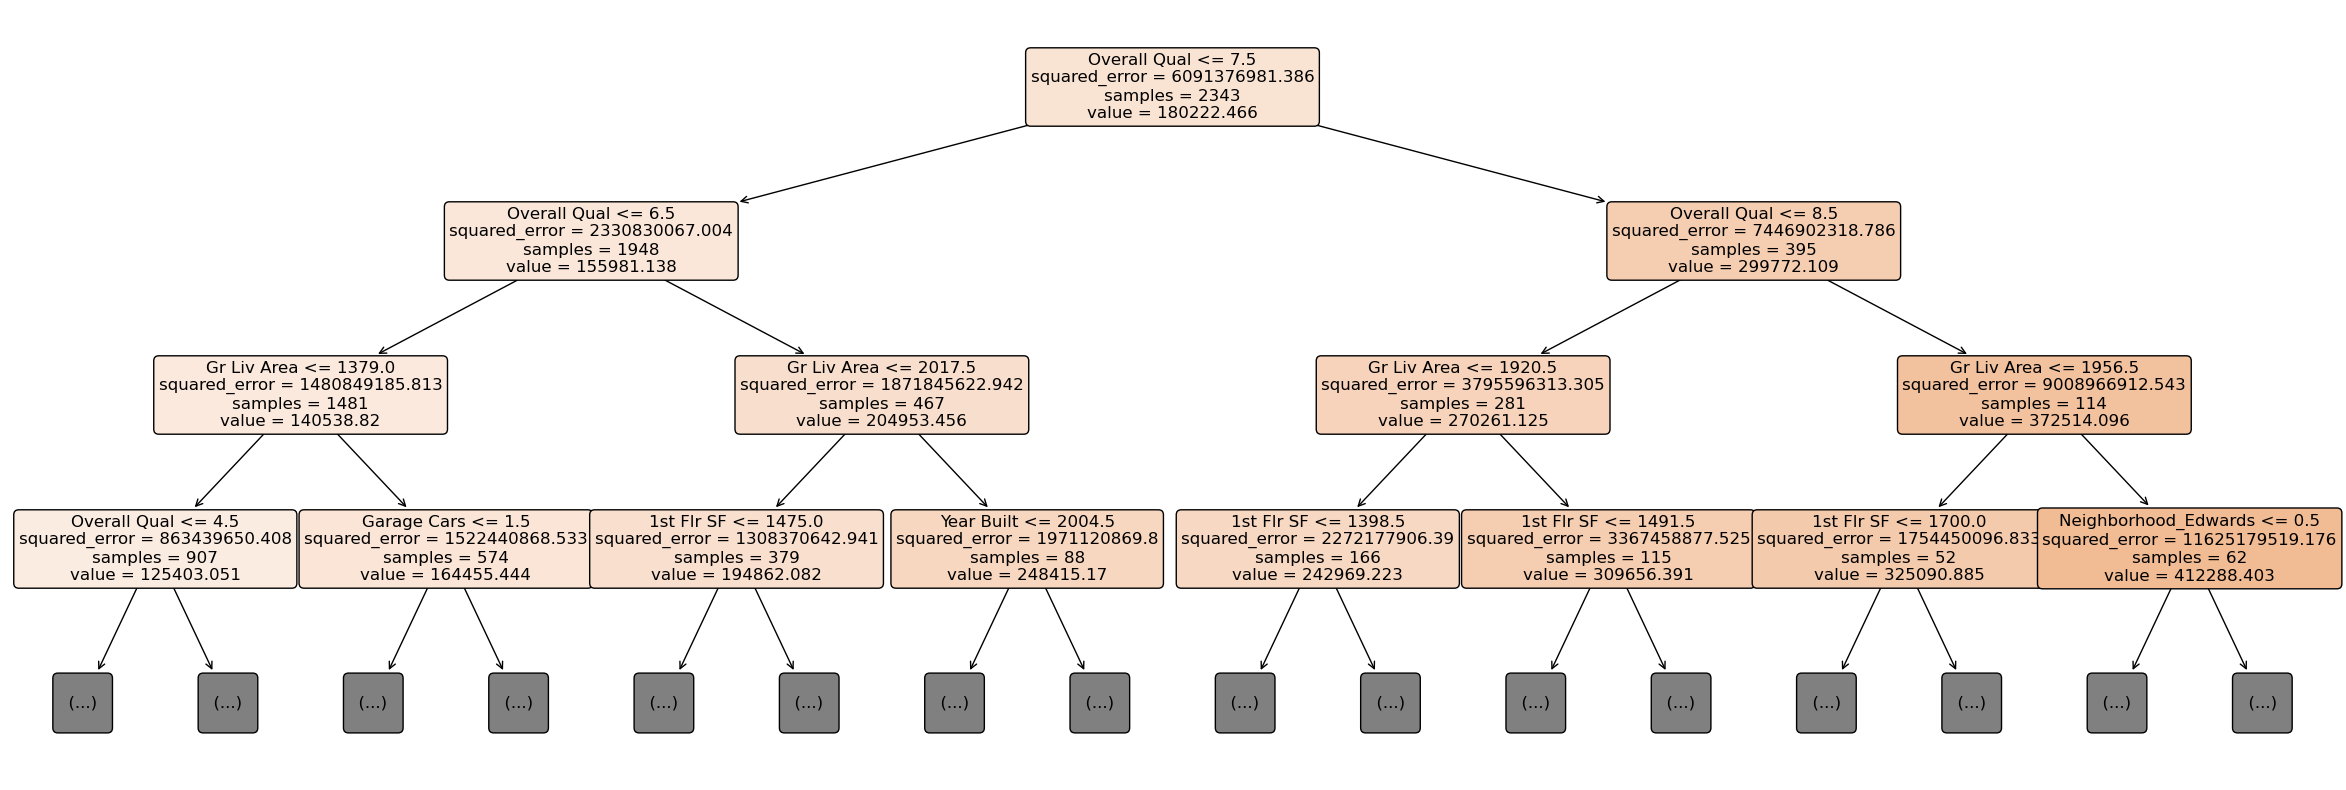

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot a partial decision tree (up to depth 3)
plt.figure(figsize=(30, 10))
plot_tree(regressor, feature_names=X.columns, filled=True, rounded=True, fontsize=12, max_depth=3)
plt.show()

## Use the model to make a prediction

Using the model, we will make a price prediction for a house currently on the market in Ames IA to predict what the price would be. In order to make a better prediction we would need to update the dataset with current Ames housing data for 2025, especially since the house was built in 2024. In our case, we will account for inflation from 2006 to 2025. 

In [15]:
import pandas as pd

new_data = pd.DataFrame({
    'Overall Qual': [10], 
    'Gr Liv Area': [1724],
    'Garage Cars': [2],
    '1st Flr SF': [1724],
    'Year Built': [2024],
    'Kitchen Qual': [4],
    'Lot Area': [9583],
    'Neighborhood': ['Sawyer'],
})

new_data_encoded = pd.get_dummies(new_data, columns=['Neighborhood'], drop_first=True)

missing_cols = set(X.columns) - set(new_data_encoded.columns)
for col in missing_cols:
    new_data_encoded[col] = 0
    
new_data_encoded = new_data_encoded[X.columns]
    
predicted_value = regressor.predict(new_data_encoded)

print("Predicted value from the model:")
print(predicted_value)
print("Predicted value accounting for inflation from 2006-2025:")
print(506031.36)



Predicted value from the model:
[318061.]
Predicted value accounting for inflation from 2006-2025:
506031.36


The prediction seems reasonable as the house in question has other homes in the area listed at around 400,000 to 500,000 dollars.